# Overture Maps Land Use Data Fetch

This notebook demonstrates how to fetch **Land Use** data from Overture Maps for a specific Area of Interest (AOI) using DuckDB and save it as a Parquet file. It then visualizes the data using GeoPandas.

**Objective:** Fetch Land Use features (e.g., residential, commercial, industrial, etc.) for the Southeastern USA.

**Tools:**
*   `duckdb`: For querying data directly from S3.
*   `geopandas`: For handling and visualizing geospatial data.
*   `shapely`: For geometric operations.

In [1]:
import duckdb
import geopandas as gpd
from shapely.geometry import box
import matplotlib.pyplot as plt

# Configuration
OVERTURE_RELEASE = "2025-11-19.0"
THEME = "base"
TYPE = "land_use"
S3_PATH = f"s3://overturemaps-us-west-2/release/{OVERTURE_RELEASE}/theme={THEME}/type={TYPE}/*"
OUTPUT_PARQUET = "overture_land_use_se_usa.parquet"

# AOI: Southeastern USA
# BBOX: (xmin, ymin, xmax, ymax)
AOI_BBOX = (-89.9190, 24.7674, -76.7229, 36.7593)

print(f"Target S3 Path: {S3_PATH}")
print(f"Area of Interest (BBOX): {AOI_BBOX}")

Target S3 Path: s3://overturemaps-us-west-2/release/2025-11-19.0/theme=base/type=land_use/*
Area of Interest (BBOX): (-89.919, 24.7674, -76.7229, 36.7593)


## 1. Fetch Data with DuckDB

We use DuckDB to query the Overture Maps Parquet files directly from S3. We filter by the bounding box to retrieve only the relevant data.

**Schema Note:** We are selecting `id`, `subtype`, `class`, and `geometry`.

In [2]:
con = duckdb.connect()

# Install and load necessary extensions
con.execute("INSTALL spatial; LOAD spatial;")
con.execute("INSTALL httpfs; LOAD httpfs;")

# Configure S3 access (anonymous for Overture)
con.execute("SET s3_region='us-west-2';")

query = f"""
COPY (
    SELECT
        id,
        subtype,
        class,
        geometry
    FROM read_parquet('{S3_PATH}')
    WHERE
        bbox.xmin > {AOI_BBOX[0]} AND
        bbox.xmax < {AOI_BBOX[2]} AND
        bbox.ymin > {AOI_BBOX[1]} AND
        bbox.ymax < {AOI_BBOX[3]}
) TO '{OUTPUT_PARQUET}' (FORMAT PARQUET, COMPRESSION 'ZSTD', ROW_GROUP_SIZE 100000);
"""

print("Executing DuckDB Query... (This may take a few minutes)")
con.execute(query)
print(f"✅ Data successfully saved to {OUTPUT_PARQUET}")
con.close()

Executing DuckDB Query... (This may take a few minutes)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

✅ Data successfully saved to overture_land_use_se_usa.parquet


## 2. Load and Visualize Data

Now we load the saved Parquet file into a GeoDataFrame and visualize the land use classes.

In [3]:
print(f"Reading {OUTPUT_PARQUET}...")
gdf = gpd.read_parquet(OUTPUT_PARQUET)
print(f"Loaded {len(gdf)} rows.")

# Display first few rows
display(gdf.head())

Reading overture_land_use_se_usa.parquet...
Loaded 1154426 rows.


,id,subtype,class,geometry
0,de01d3d0-9ea8-315e-a206-4ca8d8e2520a,cemetery,cemetery,"POLYGON ((-79.10079 36.75185, -79.10026 36.752..."
1,415cf351-4673-3cd1-90d3-06f8e2ad0fb2,cemetery,cemetery,"POLYGON ((-79.05233 36.74917, -79.05213 36.749..."
2,d7c98516-ed81-3d60-bb88-c76faeb6fe3b,cemetery,grave_yard,"POLYGON ((-79.00471 36.75289, -79.00442 36.752..."
3,a703c613-b9e4-3d96-904b-d8f501d21f21,education,school,"POLYGON ((-78.96111 36.75264, -78.95991 36.751..."
4,b4980f91-50e8-335b-b9b0-d133a65f90ca,developed,industrial,"POLYGON ((-78.95405 36.7496, -78.95438 36.7494..."


/var/folders/71/3fjqkxbs6w3frshvsfj30fmm0000gn/T/ipykernel_83630/659112439.py:6: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


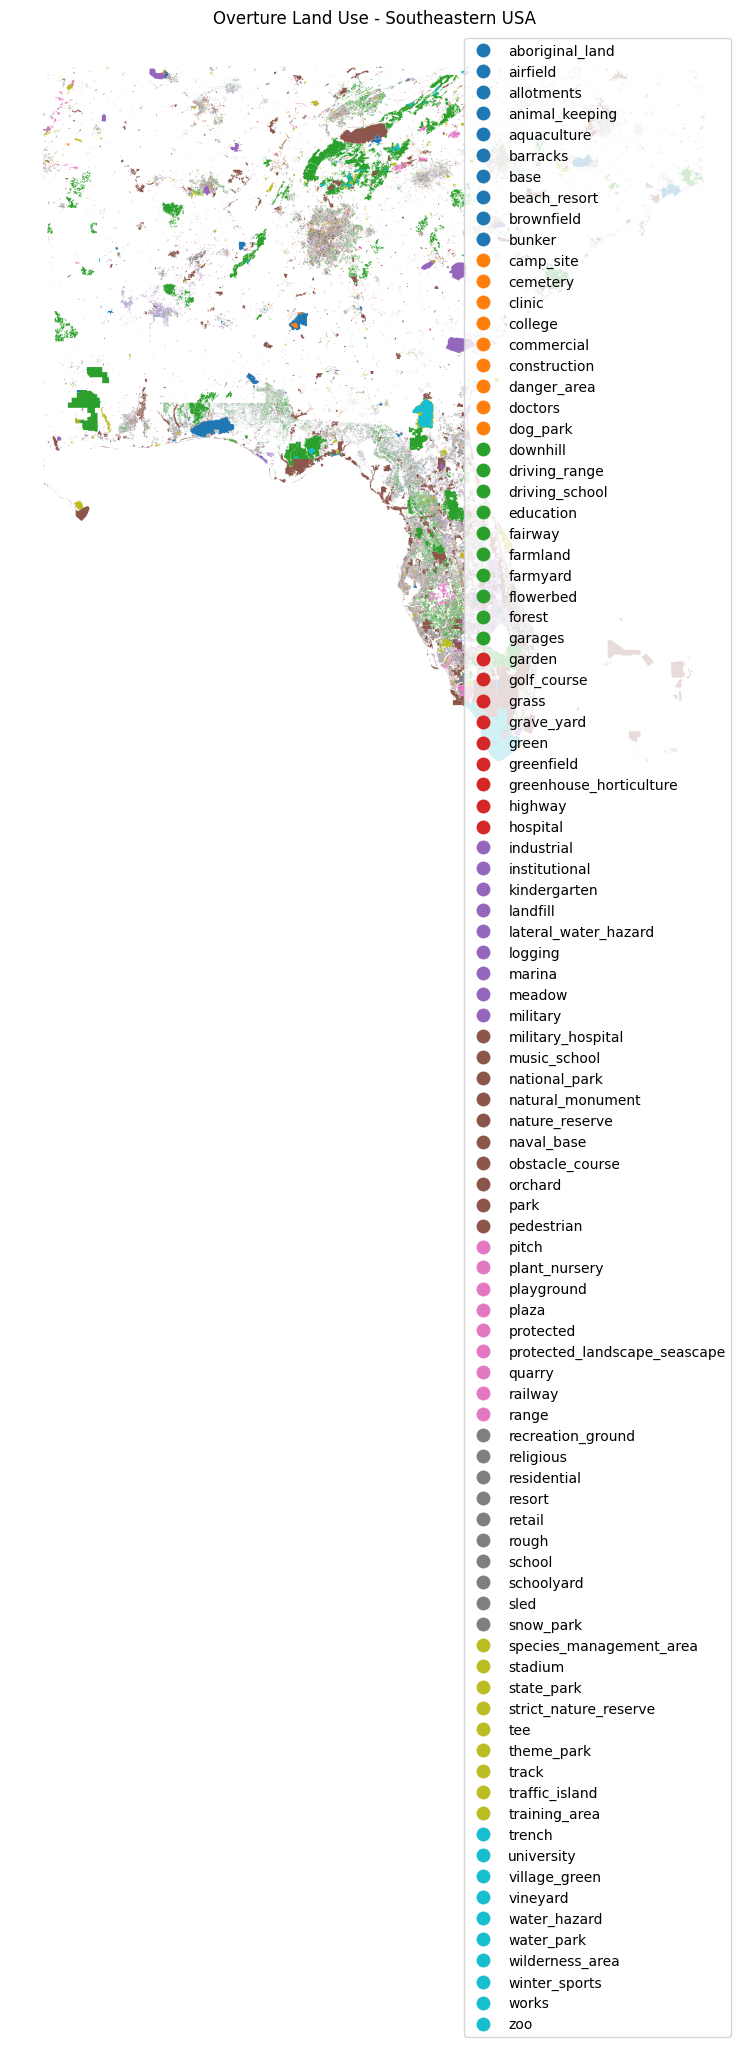

In [4]:
# Plotting
fig, ax = plt.subplots(figsize=(12, 10))
gdf.plot(column='class', ax=ax, legend=True, legend_kwds={'bbox_to_anchor': (1, 1)})
ax.set_title("Overture Land Use - Southeastern USA")
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [5]:
# Summary of Land Use Classes
print("Land Use Class Distribution:")
print(gdf['class'].value_counts())

Land Use Class Distribution:
class
residential              309323
grass                     97263
pitch                     92863
meadow                    83223
farmland                  79979
                          ...  
strict_nature_reserve         7
music_school                  5
military_hospital             2
trench                        1
naval_base                    1
Name: count, Length: 95, dtype: int64
